Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


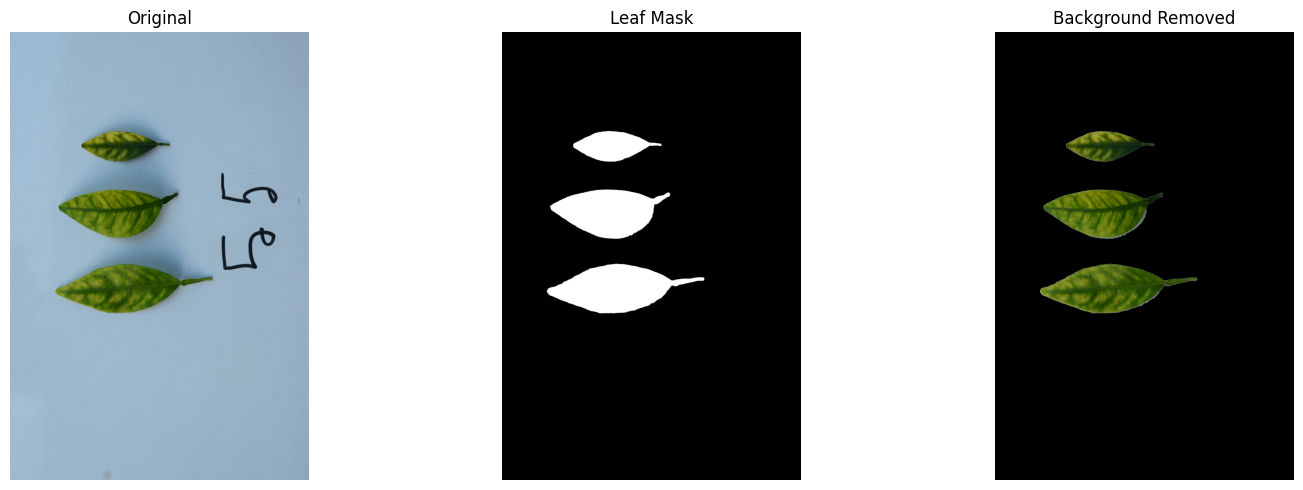

Number of leaves detected: 3
Saved to: /content/drive/MyDrive/14october/leaf_no_background145.jpg


In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Load image
image_path = '/content/drive/MyDrive/14october/DSC_Hira_Oct_14 (145).JPG'  # Adjust path
original = cv2.imread(image_path)
if original is None:
    raise ValueError("Image not found!")

# Convert to HSV color space
hsv = cv2.cvtColor(original, cv2.COLOR_BGR2HSV)

# Very aggressive blue range to catch all blue/cyan tones
lower_blue = np.array([80, 20, 20])    # Very wide range
upper_blue = np.array([140, 255, 255])

# Create mask for blue background
blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)

# Invert mask (we want leaves, not background)
leaf_mask = cv2.bitwise_not(blue_mask)

# Very aggressive morphological operations
kernel_large = np.ones((9, 9), np.uint8)
leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_CLOSE, kernel_large, iterations=4)
leaf_mask = cv2.morphologyEx(leaf_mask, cv2.MORPH_OPEN, kernel_large, iterations=2)

# Aggressive erosion to completely remove contaminated edges
kernel_erode = np.ones((5, 5), np.uint8)
leaf_mask = cv2.erode(leaf_mask, kernel_erode, iterations=4)  # Increased to 4

# Remove small noise by filtering contours
contours, _ = cv2.findContours(leaf_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
min_area = 1000
cleaned_mask = np.zeros_like(leaf_mask)

for cnt in contours:
    if cv2.contourArea(cnt) > min_area:
        cv2.drawContours(cleaned_mask, [cnt], -1, 255, thickness=cv2.FILLED)

# Dilate back to restore size (but edges are now clean)
kernel_dilate = np.ones((7, 7), np.uint8)
cleaned_mask = cv2.dilate(cleaned_mask, kernel_dilate, iterations=3)  # More dilation

# Heavy smoothing
cleaned_mask = cv2.GaussianBlur(cleaned_mask, (11, 11), 0)
_, cleaned_mask = cv2.threshold(cleaned_mask, 127, 255, cv2.THRESH_BINARY)

# Apply mask to original image
mask_3ch = cv2.cvtColor(cleaned_mask, cv2.COLOR_GRAY2BGR)
result = cv2.bitwise_and(original, mask_3ch)

# Convert to RGB for display
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
mask_rgb = cv2.cvtColor(cleaned_mask, cv2.COLOR_GRAY2RGB)

# Display
plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(original_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask_rgb)
plt.title('Leaf Mask')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(result_rgb)
plt.title('Background Removed')
plt.axis('off')

plt.tight_layout()
plt.show()

# Count leaves
valid_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_area]
print(f"Number of leaves detected: {len(valid_contours)}")

# Save
output_path = '/content/drive/MyDrive/14october/leaf_no_background145.jpg'
cv2.imwrite(output_path, result)
print(f"Saved to: {output_path}")